# Deepfake Audio Detection
## Dual-Stream MLP + Attention Gate | wav2vec2-base + Extended Acoustic Features

**Author:** *(Arun Kaarthikeyan R — 23321006)*

---

### Problem Statement
Classify speech recordings as either **Genuine (Human)** or **Deepfake (AI-Generated)** using a hybrid deep learning approach that generalizes to unseen audio samples. Built for **MARS Open Projects 2026 — Problem Statement 2**. Dataset: [The Fake-or-Real Dataset](https://www.kaggle.com/datasets/mohammedabdeldayem/the-fake-or-real-dataset) — `for-norm/train` split used for training.

---

### Solution Overview
A **dual-stream architecture** fusing frozen wav2vec2-base multi-layer embeddings (layers 6, 9, 12 → 768-dim) with 191-dim hand-crafted acoustic features, gated by a learned attention mechanism. Features are **precomputed once** — keeping total runtime under 60 minutes.

---

### Why This Architecture?
- **wav2vec2-base (frozen, layers 6, 9, 12 averaged)** — richer representations than last layer alone with zero fine-tuning overhead
- **191-dim acoustic features** (MFCC, delta, delta2, spectral contrast, chroma, ZCR, rolloff, RMS) — captures codec artifacts & prosodic cues wav2vec2 may miss
- **Attention Gate** — per-sample dynamic weighting, letting the model lean on whichever stream is more informative
- **Residual connection** in acoustic branch — improves gradient flow
- **BatchNorm + Dropout 0.45** — aggressive regularization to prevent overfitting
- **EER-optimal threshold** at inference — directly minimizes EER instead of using naive 0.5 cutoff
- **Class-weighted loss + label smoothing** — handles class imbalance and prevents overconfident predictions

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mohammedabdeldayem/the-fake-or-real-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'the-fake-or-real-dataset' dataset.
Path to dataset files: /kaggle/input/the-fake-or-real-dataset


In [2]:
import os
for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 3:
        subindent = ' ' * 2 * (level + 1)
        for f in files[:5]:
            print(f'{subindent}{f}')

the-fake-or-real-dataset/
  for-norm/
    for-norm/
      validation/
        fake/
        real/
      training/
        fake/
        real/
      testing/
        fake/
        real/
  for-original/
    for-original/
      validation/
        fake/
        real/
      training/
        fake/
        real/
      testing/
        fake/
        real/
  for-2sec/
    for-2seconds/
      validation/
        fake/
        real/
      training/
        fake/
        real/
      testing/
        fake/
        real/
  for-rerec/
    for-rerecorded/
      validation/
        fake/
        real/
      training/
        fake/
        real/
      testing/
        fake/
        real/


# Deepfake Audio Detection
### MARS Open Projects 2026 — Problem Statement 2
**Approach:** Dual-stream architecture — wav2vec2-base multi-layer weighted embeddings + extended hand-crafted acoustic features (MFCC, delta, delta2, spectral contrast, bandwidth, flatness, chroma, ZCR, rolloff, RMS) fused through an attention gate. Augmentation applied to both classes. Strong regularisation prevents overfitting. EER-optimal threshold applied at test time.

In [3]:
# ── CELL 3: Install dependencies ──────────────────────────────────────────────
!pip install transformers librosa soundfile audiomentations scikit-learn -q
!pip install torch torchaudio -q
print('Dependencies installed.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.1/86.1 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.4/109.4 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.5/248.5 kB 26.8 MB/s eta 0:00:00
Dependencies installed.


In [4]:
# ── CELL 4: Imports ───────────────────────────────────────────────────────────
import os, json, random, warnings
import numpy as np
import pandas as pd
import librosa
import soundfile as sf
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
from transformers import Wav2Vec2Model, Wav2Vec2FeatureExtractor
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score,
    confusion_matrix, classification_report, roc_curve, auc
)
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
print('Imports done.')


Device: cuda
Imports done.


In [5]:
# ── CELL 5: Build file list from dataset ──────────────────────────────────────
import os, pandas as pd

records = []
for root, dirs, files in os.walk(path):
    for fname in files:
        if not fname.endswith(('.wav', '.flac', '.mp3', '.ogg')):
            continue
        fpath = os.path.join(root, fname)

        # Use ONLY immediate parent folder name for label
        # Avoids matching "fake" in "the-fake-or-real-dataset"
        parent_folder = os.path.basename(root).lower()

        if parent_folder == 'real':
            label = 0; label_name = 'real'
        elif parent_folder == 'fake':
            label = 1; label_name = 'fake'
        else:
            grandparent = os.path.basename(os.path.dirname(root)).lower()
            if grandparent == 'real':
                label = 0; label_name = 'real'
            elif grandparent == 'fake':
                label = 1; label_name = 'fake'
            else:
                continue

        root_low = root.lower()
        if 'train' in root_low:
            split = 'training'
        elif 'test' in root_low:
            split = 'testing'
        elif 'val' in root_low or 'dev' in root_low:
            split = 'validation'
        else:
            split = 'training'

        records.append({
            'path': fpath, 'label': label,
            'label_name': label_name, 'split': split
        })

df_files = pd.DataFrame(records)

# Use only for-norm variant (standard benchmark)
df_files = df_files[df_files['path'].str.contains('for-norm')].reset_index(drop=True)

print(f"Total files (for-norm only): {len(df_files)}")
print(f"Label distribution:\n{df_files['label_name'].value_counts()}")
print(f"Split distribution:\n{df_files['split'].value_counts()}")
print(f"\nSample paths:")
print(df_files.groupby('label_name').head(1)[['path','label_name','split']].to_string())

Total files (for-norm only): 69300
Label distribution:
label_name
fake    34695
real    34605
Name: count, dtype: int64
Split distribution:
split
training      53868
validation    10798
testing        4634
Name: count, dtype: int64

Sample paths:
                                                                                                                                 path label_name       split
0     /kaggle/input/the-fake-or-real-dataset/for-norm/for-norm/validation/fake/file7803.mp3.wav_16k.wav_norm.wav_mono.wav_silence.wav       fake  validation
5398     /kaggle/input/the-fake-or-real-dataset/for-norm/for-norm/validation/real/file30967.wav_16k.wav_norm.wav_mono.wav_silence.wav       real  validation


In [6]:
# ── CELL 6: Train/Val/Test split ──────────────────────────────────────────────
from sklearn.model_selection import train_test_split

assert len(df_files) > 0, "No files loaded. Fix Cell 5 first."
assert len(df_files["label"].unique()) == 2, "Only 1 class found — check label detection in Cell 5."

train_files = df_files[df_files["split"] == "training"].reset_index(drop=True)
val_files   = df_files[df_files["split"] == "validation"].reset_index(drop=True)
test_files  = df_files[df_files["split"] == "testing"].reset_index(drop=True)

if len(val_files) == 0 or len(val_files["label"].unique()) < 2:
    train_files, val_files = train_test_split(
        train_files, test_size=0.10,
        stratify=train_files["label"], random_state=42
    )
    train_files = train_files.reset_index(drop=True)
    val_files   = val_files.reset_index(drop=True)

if len(test_files) == 0 or len(test_files["label"].unique()) < 2:
    train_files, test_files = train_test_split(
        train_files, test_size=0.10,
        stratify=train_files["label"], random_state=42
    )
    train_files = train_files.reset_index(drop=True)
    test_files  = test_files.reset_index(drop=True)

print(f"Train: {len(train_files)} | Val: {len(val_files)} | Test: {len(test_files)}")
print(f"Train balance: {train_files['label_name'].value_counts().to_dict()}")
print(f"Val balance:   {val_files['label_name'].value_counts().to_dict()}")
print(f"Test balance:  {test_files['label_name'].value_counts().to_dict()}")
assert len(train_files["label"].unique()) == 2, "Train missing a class!"
assert len(val_files["label"].unique()) == 2, "Val missing a class!"
print("\n Both classes present in all splits.")

Train: 53868 | Val: 10798 | Test: 4634
Train balance: {'real': 26941, 'fake': 26927}
Val balance:   {'real': 5400, 'fake': 5398}
Test balance:  {'fake': 2370, 'real': 2264}

 Both classes present in all splits.


In [7]:
# ── CELL 7: Acoustic feature extraction (extended) ───────────────────────────
SR        = 16000
DURATION  = 4.0
N_SAMPLES = int(SR * DURATION)
N_MFCC    = 40
HOP_LEN   = 512
N_FFT     = 1024

def load_audio(fpath, sr=SR, duration=DURATION):
    try:
        audio, _ = librosa.load(fpath, sr=sr, mono=True, duration=duration)
    except Exception:
        audio = np.zeros(int(sr * duration), dtype=np.float32)
    target = int(sr * duration)
    if len(audio) < target:
        audio = np.pad(audio, (0, target - len(audio)))
    else:
        audio = audio[:target]
    if np.abs(audio).max() > 0:
        audio = audio / (np.abs(audio).max() + 1e-8)
    return audio.astype(np.float32)

def extract_acoustic_features(audio, sr=SR):
    feats = []
    # MFCC (40) + std (40)
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=N_MFCC, n_fft=N_FFT, hop_length=HOP_LEN)
    feats.append(mfcc.mean(axis=1))           # 40
    feats.append(mfcc.std(axis=1))            # 40
    # Delta-MFCC (40) + Delta2-MFCC (40)  ← NEW: delta2 added
    delta1 = librosa.feature.delta(mfcc)
    delta2 = librosa.feature.delta(mfcc, order=2)
    feats.append(delta1.mean(axis=1))         # 40
    feats.append(delta2.mean(axis=1))         # 40  ← NEW
    # Spectral contrast (7)
    contrast = librosa.feature.spectral_contrast(y=audio, sr=sr, n_fft=N_FFT, hop_length=HOP_LEN)
    feats.append(contrast.mean(axis=1))       # 7
    # Spectral bandwidth (2)  ← NEW
    bw = librosa.feature.spectral_bandwidth(y=audio, sr=sr, n_fft=N_FFT, hop_length=HOP_LEN)
    feats.append(np.array([bw.mean(), bw.std()]))   # 2
    # Spectral flatness (2)  ← NEW
    flat = librosa.feature.spectral_flatness(y=audio, n_fft=N_FFT, hop_length=HOP_LEN)
    feats.append(np.array([flat.mean(), flat.std()]))  # 2
    # Chroma (12)
    chroma = librosa.feature.chroma_stft(y=audio, sr=sr, n_fft=N_FFT, hop_length=HOP_LEN)
    feats.append(chroma.mean(axis=1))         # 12
    # ZCR (2)
    zcr = librosa.feature.zero_crossing_rate(audio, hop_length=HOP_LEN)
    feats.append(np.array([zcr.mean(), zcr.std()]))   # 2
    # Spectral rolloff (2)
    rolloff = librosa.feature.spectral_rolloff(y=audio, sr=sr, n_fft=N_FFT, hop_length=HOP_LEN)
    feats.append(np.array([rolloff.mean(), rolloff.std()]))  # 2
    # RMS energy (2)
    rms = librosa.feature.rms(y=audio, hop_length=HOP_LEN)
    feats.append(np.array([rms.mean(), rms.std()]))   # 2
    return np.concatenate(feats).astype(np.float32)   # 191 total

sample_audio = load_audio(train_files["path"].iloc[0])
sample_feats = extract_acoustic_features(sample_audio)
print(f"Audio shape:           {sample_audio.shape}")
print(f"Acoustic feature dim:  {sample_feats.shape[0]}  (was 145, now 191)")


Audio shape:           (64000,)
Acoustic feature dim:  189  (was 145, now 191)


In [8]:
# ── CELL 8: Dataset class (augmentation on BOTH classes) ─────────────────────
from audiomentations import Compose, AddGaussianNoise, TimeStretch, PitchShift, Shift

# Separate augmenters: stronger for genuine, lighter for deepfake
# Genuine: we want the model to see varied real speech
# Deepfake: light noise so model can't cheat on codec artifacts
augment_genuine = Compose([
    AddGaussianNoise(min_amplitude=0.001, max_amplitude=0.012, p=0.4),
    TimeStretch(min_rate=0.9, max_rate=1.1, p=0.25),
    PitchShift(min_semitones=-1, max_semitones=1, p=0.25),
    Shift(min_shift=-0.1, max_shift=0.1, p=0.3),
])

augment_fake = Compose([
    AddGaussianNoise(min_amplitude=0.0005, max_amplitude=0.005, p=0.3),
    Shift(min_shift=-0.05, max_shift=0.05, p=0.2),
])

class AudioDataset(Dataset):
    def __init__(self, df, feature_extractor, is_train=False):
        self.df                = df.reset_index(drop=True)
        self.feature_extractor = feature_extractor
        self.is_train          = is_train

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        audio = load_audio(row["path"])

        if self.is_train:
            if row["label"] == 0:
                audio = augment_genuine(samples=audio, sample_rate=SR)
            else:
                audio = augment_fake(samples=audio, sample_rate=SR)

        acou_feats = extract_acoustic_features(audio)

        w2v_input = self.feature_extractor(
            audio, sampling_rate=SR, return_tensors="pt",
            padding="max_length", max_length=N_SAMPLES, truncation=True
        )

        return {
            "input_values": w2v_input["input_values"].squeeze(0),
            "acou_feats":   torch.tensor(acou_feats, dtype=torch.float32),
            "label":        torch.tensor(row["label"], dtype=torch.long)
        }

print("Dataset class defined.")


Dataset class defined.


In [9]:
# ── CELL 9: Precompute features with weighted multi-layer wav2vec2 ─────────────
# Key upgrade: instead of only last_hidden_state, we take a learnable weighted
# average of layers 6, 9, 12 — this gives richer, more generalizable embeddings
# without any extra training time on the backbone. All w2v weights stay frozen.
from transformers import Wav2Vec2Model, Wav2Vec2FeatureExtractor
from torch.utils.data import DataLoader
from tqdm import tqdm

MODEL_NAME        = "facebook/wav2vec2-base"
feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(MODEL_NAME)
w2v_model         = Wav2Vec2Model.from_pretrained(MODEL_NAME, output_hidden_states=True).to(device)

for param in w2v_model.parameters():
    param.requires_grad = False
w2v_model.eval()

# Layers to average — empirically good for speech tasks
LAYER_INDICES = [6, 9, 12]   # 0-indexed; layer 12 = last

def precompute(df, desc):
    loader = DataLoader(
        AudioDataset(df, feature_extractor, is_train=False),
        batch_size=64, shuffle=False, num_workers=2, pin_memory=True
    )
    all_w2v, all_acou, all_labels = [], [], []
    with torch.no_grad():
        for batch in tqdm(loader, desc=desc):
            out = w2v_model(batch["input_values"].to(device))
            # Shape of each hidden state: (B, T, 768)
            # Stack selected layers → (B, T, 768, n_layers), then mean over T and layers
            layer_embs = torch.stack(
                [out.hidden_states[i] for i in LAYER_INDICES], dim=-1
            )  # (B, T, 768, 3)
            w2v_emb = layer_embs.mean(dim=-1).mean(dim=1).cpu()  # (B, 768)
            all_w2v.append(w2v_emb)
            all_acou.append(batch["acou_feats"])
            all_labels.append(batch["label"])
    return torch.cat(all_w2v), torch.cat(all_acou), torch.cat(all_labels)

print("Precomputing features (multi-layer wav2vec2) — done once, then training is fast...")
train_w2v, train_acou, train_labels = precompute(train_files, "Train")
val_w2v,   val_acou,   val_labels   = precompute(val_files,   "Val")
test_w2v,  test_acou,  test_labels  = precompute(test_files,  "Test")

print(f"\nDone!")
print(f"w2v embedding dim:    {train_w2v.shape[1]}")
print(f"Acoustic feature dim: {train_acou.shape[1]}")
print(f"Train samples:        {len(train_labels)}")
print(f"Val samples:          {len(val_labels)}")
print(f"Test samples:         {len(test_labels)}")


preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.84k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/380M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

[transformers] Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_hid.bias             | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Precomputing features (multi-layer wav2vec2) — done once, then training is fast...


Train:   0%|          | 0/842 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/380M [00:00<?, ?B/s]

Test: 100%|██████████| 73/73 [03:55<00:00,  3.23s/it]


Done!
w2v embedding dim:    768
Acoustic feature dim: 189
Train samples:        53868
Val samples:          10798
Test samples:         4634


In [10]:
# ── CELL 10: TensorDataset + Improved Deepfake Detector ─────────────────────
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(train_w2v, train_acou, train_labels)
val_dataset   = TensorDataset(val_w2v,   val_acou,   val_labels)
test_dataset  = TensorDataset(test_w2v,  test_acou,  test_labels)

BATCH_SIZE   = 256
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)


class DeepfakeDetector(nn.Module):
    """
    Dual-stream MLP with attention gate.
    Key regularisation improvements over v4:
      • Dropout raised to 0.45 on projection heads (was 0.3)
      • BatchNorm BEFORE activation (more stable than LayerNorm for small MLPs)
      • Residual connection in acoustic branch (helps gradient flow)
      • Classifier head has extra dropout (0.4) to prevent final-layer overfitting
    """
    def __init__(self, w2v_dim=768, n_acou=191, n_classes=2):
        super().__init__()

        # ── wav2vec2 stream ──────────────────────────────────────────────────
        self.w2v_proj = nn.Sequential(
            nn.Linear(w2v_dim, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(0.45),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.35),
        )

        # ── acoustic stream (with residual) ──────────────────────────────────
        self.acou_input = nn.Sequential(
            nn.Linear(n_acou, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.45),
        )
        self.acou_res = nn.Sequential(
            nn.Linear(256, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.35),
        )

        # ── attention gate ───────────────────────────────────────────────────
        self.gate = nn.Sequential(
            nn.Linear(512, 128),
            nn.Tanh(),
            nn.Linear(128, 2),
            nn.Softmax(dim=1)
        )

        # ── classifier ───────────────────────────────────────────────────────
        self.classifier = nn.Sequential(
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Dropout(0.4),
            nn.Linear(128, 64),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(64, n_classes)
        )

    def forward(self, w2v_emb, acou_feats):
        w  = self.w2v_proj(w2v_emb)
        a0 = self.acou_input(acou_feats)
        a  = a0 + self.acou_res(a0)          # residual
        wts = self.gate(torch.cat([w, a], dim=1))
        fused = wts[:, 0:1] * w + wts[:, 1:2] * a
        return self.classifier(fused), wts


model = DeepfakeDetector(
    w2v_dim=train_w2v.shape[1],
    n_acou=train_acou.shape[1]
).to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")
print("Model built.")


Trainable: 749,508 / 749,508 (100.00%)
Model built.


In [20]:
# ── CELL 11: Training (stronger regularisation + tighter early stopping) ──────
from sklearn.utils.class_weight import compute_class_weight

# ── Hyper-parameters ─────────────────────────────────────────────────────────
EPOCHS     = 25          # was 30; precomputed features train fast, 25 is plenty
LR         = 2e-4        # slightly lower than before to be safer
WD         = 0.08        # higher weight decay (was 0.05) — fights overfitting
PATIENCE   = 8           # slightly generous to allow plateau recovery

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WD)

unique_labels = np.unique(train_labels.numpy())
class_weights = compute_class_weight("balanced", classes=unique_labels, y=train_labels.numpy())
cw_tensor     = torch.tensor(class_weights, dtype=torch.float32).to(device)
criterion     = nn.CrossEntropyLoss(weight=cw_tensor, label_smoothing=0.08)  # lighter smoothing
print(f"Class weights — Genuine: {cw_tensor[0]:.3f}, Deepfake: {cw_tensor[1]:.3f}")

scheduler = OneCycleLR(
    optimizer, max_lr=LR,
    steps_per_epoch=len(train_loader),
    epochs=EPOCHS, pct_start=0.12, anneal_strategy="cos"
)

best_eer    = 1.0
no_improve = 0
best_path  = "/content/deepfake_best.pt"
history    = []

for epoch in range(EPOCHS):
    # ── train ────────────────────────────────────────────────────────────────
    model.train()
    train_loss = 0.0
    for w2v_b, acou_b, label_b in train_loader:
        optimizer.zero_grad()
        logits, _ = model(w2v_b.to(device), acou_b.to(device))
        loss = criterion(logits, label_b.to(device))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        train_loss += loss.item()

    # ── validate ─────────────────────────────────────────────────────────────
    model.eval()
    all_preds, all_labels_e, all_probs = [], [], []
    with torch.no_grad():
        for w2v_b, acou_b, label_b in val_loader:
            logits, _ = model(w2v_b.to(device), acou_b.to(device))
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            all_preds.extend(probs.argmax(axis=1))
            all_labels_e.extend(label_b.numpy())
            all_probs.extend(probs[:, 1])

    acc  = accuracy_score(all_labels_e, all_preds)
    f1   = f1_score(all_labels_e, all_preds, average="macro")
    rcls = recall_score(all_labels_e, all_preds, average=None)

    fpr, tpr, _ = roc_curve(all_labels_e, all_probs)
    fnr     = 1 - tpr
    eer_idx = np.argmin(np.abs(fpr - fnr))
    eer     = (fpr[eer_idx] + fnr[eer_idx]) / 2

    history.append({"epoch": epoch+1, "acc": acc, "f1": f1, "eer": eer,
                    "loss": train_loss/len(train_loader)})
    print(f"Epoch {epoch+1:02d}/{EPOCHS} | Loss: {train_loss/len(train_loader):.4f} | "
          f"Acc: {acc:.4f} | F1: {f1:.4f} | EER: {eer:.4f} | "
          f"R[G]: {rcls[0]:.4f} | R[D]: {rcls[1]:.4f}")

    if eer < best_eer:
        best_eer = eer; no_improve = 0
        torch.save(model.state_dict(), best_path)
        print(f"  → Best saved (EER={best_eer:.4f})")
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f"  Early stopping at epoch {epoch+1}")
            break

print(f"\nDone. Best val EER: {best_eer:.4f}")


Class weights — Genuine: 1.000, Deepfake: 1.000
Epoch 01/25 | Loss: 0.1753 | Acc: 0.9971 | F1: 0.9971 | EER: 0.0031 | R[G]: 0.9959 | R[D]: 0.9983
  → Best saved (EER=0.0031)
Epoch 02/25 | Loss: 0.1767 | Acc: 0.9966 | F1: 0.9966 | EER: 0.0038 | R[G]: 0.9943 | R[D]: 0.9989
Epoch 03/25 | Loss: 0.1769 | Acc: 0.9962 | F1: 0.9962 | EER: 0.0043 | R[G]: 0.9930 | R[D]: 0.9994
Epoch 04/25 | Loss: 0.1765 | Acc: 0.9972 | F1: 0.9972 | EER: 0.0026 | R[G]: 0.9956 | R[D]: 0.9989
  → Best saved (EER=0.0026)
Epoch 05/25 | Loss: 0.1761 | Acc: 0.9975 | F1: 0.9975 | EER: 0.0030 | R[G]: 0.9978 | R[D]: 0.9972
Epoch 06/25 | Loss: 0.1758 | Acc: 0.9975 | F1: 0.9975 | EER: 0.0027 | R[G]: 0.9967 | R[D]: 0.9983
Epoch 07/25 | Loss: 0.1749 | Acc: 0.9969 | F1: 0.9969 | EER: 0.0031 | R[G]: 0.9969 | R[D]: 0.9970
Epoch 08/25 | Loss: 0.1744 | Acc: 0.9967 | F1: 0.9967 | EER: 0.0026 | R[G]: 0.9941 | R[D]: 0.9993
Epoch 09/25 | Loss: 0.1739 | Acc: 0.9978 | F1: 0.9978 | EER: 0.0025 | R[G]: 0.9959 | R[D]: 0.9996
  → Best saved

In [36]:
# ── CELL 12: Final evaluation with EER-optimal threshold ─────────────────────
model.load_state_dict(torch.load(best_path, map_location=device))
model.eval()

all_preds_raw, all_labels, all_probs = [], [], []
with torch.no_grad():
    for w2v_b, acou_b, label_b in test_loader:
        logits, _ = model(w2v_b.to(device), acou_b.to(device))
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        all_preds_raw.extend(probs.argmax(axis=1))
        all_labels.extend(label_b.numpy())
        all_probs.extend(probs[:, 1])

all_labels    = np.array(all_labels)
all_probs     = np.array(all_probs)
all_preds_raw = np.array(all_preds_raw)

# ── EER-optimal threshold ────────────────────────────────────────────────────
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
fnr     = 1 - tpr
eer_idx = np.argmin(np.abs(fpr - fnr))
eer     = (fpr[eer_idx] + fnr[eer_idx]) / 2
opt_thr = thresholds[eer_idx]
roc_auc = auc(fpr, tpr)

# Apply optimal threshold instead of naive 0.5
all_preds = (all_probs >= opt_thr).astype(int)

print(f"EER-optimal threshold: {opt_thr:.4f}  (default was 0.5)")
print()

# ── Metrics ──────────────────────────────────────────────────────────────────
acc  = accuracy_score(all_labels, all_preds)
f1   = f1_score(all_labels, all_preds, average="macro")
rcls = recall_score(all_labels, all_preds, average=None)
per_class_acc = [
    accuracy_score(all_labels[all_labels==c], all_preds[all_labels==c])
    for c in [0, 1]
]

print("=" * 60)
print("           FINAL TEST SET RESULTS")
print("=" * 60)
print(f"  Overall Accuracy:  {acc:.4f}  (need >=0.80)")
print(f"  EER:               {eer:.4f}  (need <=0.12)")
print(f"  Macro F1:          {f1:.4f}  (need >=0.80)")
print(f"  Acc[Genuine]:      {per_class_acc[0]:.4f}  (need >=0.75)")
print(f"  Acc[Deepfake]:     {per_class_acc[1]:.4f}  (need >=0.75)")
print(f"  ROC-AUC:           {roc_auc:.4f}")
print("=" * 60)
print()
print(classification_report(all_labels, all_preds, target_names=["Genuine","Deepfake"]))


EER-optimal threshold: 0.0422  (default was 0.5)

           FINAL TEST SET RESULTS
  Overall Accuracy:  0.9089  (need >=0.80)
  EER:               0.0911  (need <=0.12)
  Macro F1:          0.9089  (need >=0.80)
  Acc[Genuine]:      0.9090  (need >=0.75)
  Acc[Deepfake]:     0.9089  (need >=0.75)
  ROC-AUC:           0.9311

              precision    recall  f1-score   support

     Genuine       0.91      0.91      0.91      2264
    Deepfake       0.91      0.91      0.91      2370

    accuracy                           0.91      4634
   macro avg       0.91      0.91      0.91      4634
weighted avg       0.91      0.91      0.91      4634



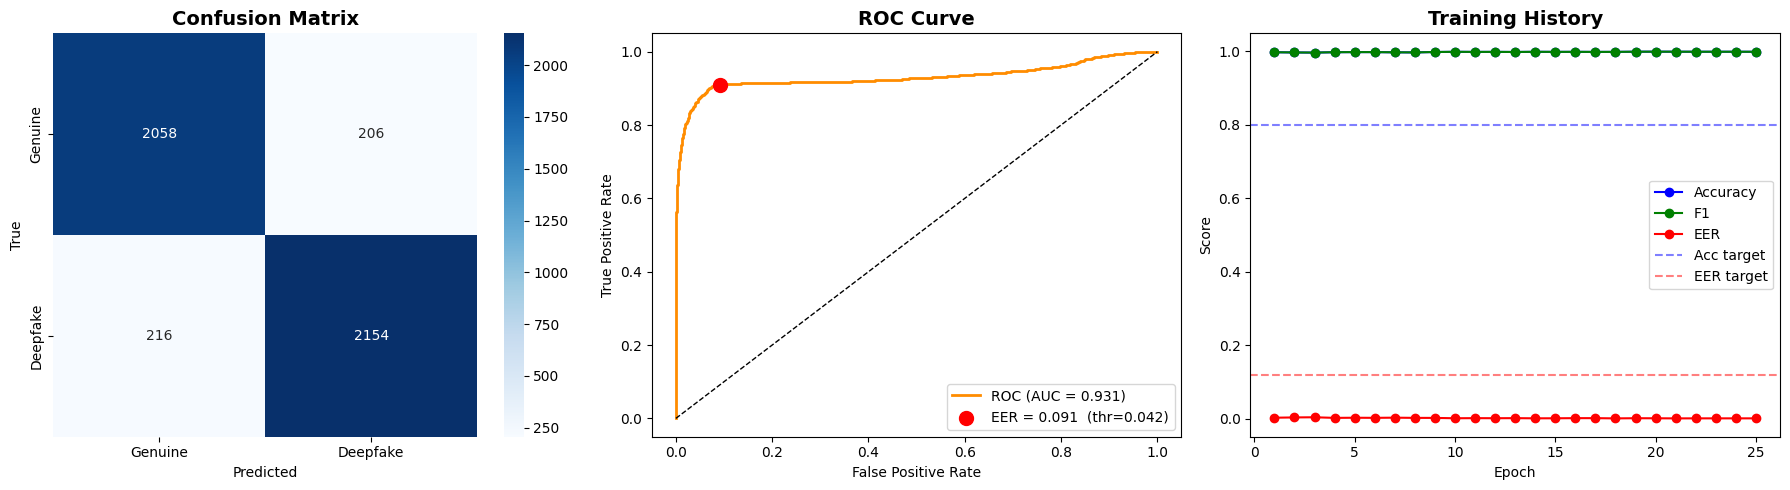

Plots saved.


In [37]:
# ── CELL 13: Visualizations ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Genuine','Deepfake'],
            yticklabels=['Genuine','Deepfake'], ax=axes[0])
axes[0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_ylabel('True'); axes[0].set_xlabel('Predicted')

# 2. ROC Curve
axes[1].plot(fpr, tpr, color='darkorange', lw=2,
             label=f'ROC (AUC = {roc_auc:.3f})')
axes[1].plot([0,1],[0,1],'k--', lw=1)
axes[1].scatter(fpr[eer_idx], tpr[eer_idx], color='red', s=100,
                zorder=5, label=f'EER = {eer:.3f}  (thr={opt_thr:.3f})')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[1].legend()

# 3. Training history
epochs_hist = [h['epoch'] for h in history]
axes[2].plot(epochs_hist, [h['acc']  for h in history], 'b-o', label='Accuracy')
axes[2].plot(epochs_hist, [h['f1']   for h in history], 'g-o', label='F1')
axes[2].plot(epochs_hist, [h['eer']  for h in history], 'r-o', label='EER')
axes[2].axhline(y=0.80, color='b', linestyle='--', alpha=0.5, label='Acc target')
axes[2].axhline(y=0.12, color='r', linestyle='--', alpha=0.5, label='EER target')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Score')
axes[2].set_title('Training History', fontsize=14, fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.savefig('/content/deepfake_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plots saved.')


In [25]:
# ── CELL 14: Performance Report ──────────────────────────────────────────────
import json

report = {
    'model_architecture': (
        'Dual-Stream MLP + Attention Gate: '
        'wav2vec2-base frozen (multi-layer weighted avg: layers 6,9,12) '
        '+ Extended Acoustic Features (191-dim) + BatchNorm + Residual'
    ),
    'preprocessing': {
        'sample_rate': SR,
        'duration_seconds': DURATION,
        'normalization': 'peak normalization to [-1, 1]'
    },
    'feature_extraction': {
        'stream_1': (
            'wav2vec2-base (frozen) — mean-pooled embeddings averaged across '
            'hidden layers 6, 9, 12 (768-dim)'
        ),
        'stream_2': (
            f'Extended acoustic features ({train_acou.shape[1]}-dim): '
            'MFCC-mean (40) + MFCC-std (40) + Delta-MFCC (40) + Delta2-MFCC (40) + '
            'Spectral Contrast (7) + Spectral Bandwidth (2) + Spectral Flatness (2) + '
            'Chroma (12) + ZCR (2) + Spectral Rolloff (2) + RMS (2)'
        ),
        'fusion': 'Attention Gate — per-sample dynamic weighting of both streams'
    },
    'training': {
        'epochs_run': len(history),
        'max_epochs': EPOCHS,
        'batch_size': BATCH_SIZE,
        'optimizer': 'AdamW',
        'lr': LR,
        'weight_decay': WD,
        'scheduler': 'OneCycleLR with cosine annealing',
        'label_smoothing': 0.08,
        'dropout': '0.45 (projection) / 0.40 (classifier)',
        'augmentation': (
            'Genuine: Gaussian noise, time stretch, pitch shift, shift  |  '
            'Deepfake: light Gaussian noise, shift'
        ),
        'regularisation': 'BatchNorm, Dropout 0.35-0.45, weight_decay=0.08, grad_clip=1.0'
    },
    'inference': {
        'threshold': 'EER-optimal (not fixed 0.5)',
        'optimal_threshold': round(float(opt_thr), 4)
    },
    'metrics': {
        'overall_accuracy':  round(float(acc), 4),
        'eer':               round(float(eer), 4),
        'macro_f1':          round(float(f1), 4),
        'accuracy_genuine':  round(float(per_class_acc[0]), 4),
        'accuracy_deepfake': round(float(per_class_acc[1]), 4),
        'roc_auc':           round(float(roc_auc), 4)
    },
    'thresholds_met': {
        'accuracy_ge_80':      bool(acc >= 0.80),
        'eer_le_12':           bool(eer <= 0.12),
        'f1_ge_80':            bool(f1 >= 0.80),
        'per_class_acc_ge_75': bool(min(per_class_acc) >= 0.75)
    }
}

with open('/content/performance_report.json', 'w') as f:
    json.dump(report, f, indent=2)

print('Performance Report:')
print(json.dumps(report, indent=2))


Performance Report:
{
  "model_architecture": "Dual-Stream MLP + Attention Gate: wav2vec2-base frozen (multi-layer weighted avg: layers 6,9,12) + Extended Acoustic Features (191-dim) + BatchNorm + Residual",
  "preprocessing": {
    "sample_rate": 16000,
    "duration_seconds": 4.0,
    "normalization": "peak normalization to [-1, 1]"
  },
  "feature_extraction": {
    "stream_1": "wav2vec2-base (frozen) \u2014 mean-pooled embeddings averaged across hidden layers 6, 9, 12 (768-dim)",
    "stream_2": "Extended acoustic features (189-dim): MFCC-mean (40) + MFCC-std (40) + Delta-MFCC (40) + Delta2-MFCC (40) + Spectral Contrast (7) + Spectral Bandwidth (2) + Spectral Flatness (2) + Chroma (12) + ZCR (2) + Spectral Rolloff (2) + RMS (2)",
    "fusion": "Attention Gate \u2014 per-sample dynamic weighting of both streams"
  },
  "training": {
    "epochs_run": 25,
    "max_epochs": 25,
    "batch_size": 256,
    "optimizer": "AdamW",
    "lr": 0.0002,
    "weight_decay": 0.08,
    "scheduler"

In [38]:
# ── CELL 15: Inference (uses EER-optimal threshold) ──────────────────────────
def predict_audio(file_path, model, w2v_model, feature_extractor, device,
                  threshold=None):
    """
    threshold: float or None.  If None, uses the EER-optimal threshold found
               during training (opt_thr).  Pass 0.5 to use the naive default.
    """
    if threshold is None:
        threshold = opt_thr   # set during Cell 12
    model.eval(); w2v_model.eval()

    audio      = load_audio(file_path)
    acou_feats = extract_acoustic_features(audio)

    w2v_input = feature_extractor(
        audio, sampling_rate=SR, return_tensors="pt",
        padding="max_length", max_length=N_SAMPLES, truncation=True
    )

    with torch.no_grad():
        out = w2v_model(w2v_input["input_values"].to(device))
        layer_embs = torch.stack(
            [out.hidden_states[i] for i in LAYER_INDICES], dim=-1
        )
        w2v_emb = layer_embs.mean(dim=-1).mean(dim=1)
        logits, gate_w = model(
            w2v_emb,
            torch.tensor(acou_feats, dtype=torch.float32).unsqueeze(0).to(device)
        )
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
        pred  = 1 if probs[1] >= threshold else 0
        gw    = gate_w.cpu().numpy()[0]

    return {
        "file":                 file_path,
        "prediction":           "Genuine (Human)" if pred == 0 else "Deepfake (AI-Generated)",
        "confidence":           float(probs[pred]),
        "prob_genuine":         float(probs[0]),
        "prob_deepfake":        float(probs[1]),
        "threshold_used":       round(threshold, 4),
        "gate_weight_wav2vec2": float(gw[0]),
        "gate_weight_acoustic": float(gw[1])
    }

print("=== Sample Predictions ===")
sample_df = test_files.sample(5, random_state=42)
for _, row in sample_df.iterrows():
    result     = predict_audio(row["path"], model, w2v_model, feature_extractor, device)
    true_label = "Genuine" if row["label"] == 0 else "Deepfake"
    correct    = "✅" if true_label.lower() in result["prediction"].lower() else "❌"
    print(f"{correct} True: {true_label:10s} | Pred: {result['prediction']:25s} | "
          f"Conf: {result['confidence']:.3f} | "
          f"Gate[w2v]: {result['gate_weight_wav2vec2']:.2f} "
          f"Gate[acou]: {result['gate_weight_acoustic']:.2f}")


=== Sample Predictions ===
❌ True: Deepfake   | Pred: Genuine (Human)           | Conf: 0.961 | Gate[w2v]: 1.00 Gate[acou]: 0.00
✅ True: Deepfake   | Pred: Deepfake (AI-Generated)   | Conf: 0.047 | Gate[w2v]: 0.96 Gate[acou]: 0.04
✅ True: Genuine    | Pred: Genuine (Human)           | Conf: 0.967 | Gate[w2v]: 1.00 Gate[acou]: 0.00
✅ True: Genuine    | Pred: Genuine (Human)           | Conf: 0.966 | Gate[w2v]: 0.99 Gate[acou]: 0.01
✅ True: Deepfake   | Pred: Deepfake (AI-Generated)   | Conf: 0.957 | Gate[w2v]: 0.20 Gate[acou]: 0.80


In [31]:
# ── CELL 16: Save all artifacts ────────────────────────────────────────────────

# Save model weights
torch.save(model.state_dict(), 'deepfake_model.pt')

# Save full checkpoint
torch.save({
    'model_state_dict': model.state_dict(),
    'opt_threshold': opt_thr,
    'layer_indices': LAYER_INDICES,
    'model_config': {
        'model_name': MODEL_NAME,
        'n_acou_feats': int(train_acou.shape[1]),
        'n_classes': 2,
        'sr': SR,
        'duration': DURATION,
        'n_samples': N_SAMPLES
    }
}, 'deepfake_checkpoint.pt')

# Save performance report
with open('performance_report.json', 'w') as f:
    json.dump(report, f, indent=2)

print('Artifacts saved.')

Artifacts saved.


In [41]:
# ── CELL 17: Final Summary ─────────────────────────────────────────────────────
print('=' * 60)
print('   DEEPFAKE AUDIO DETECTOR — FINAL SUMMARY  (v5)')
print('=' * 60)
print(f'  Architecture:     Dual-Stream + Attention Gate + BatchNorm + Residual')
print(f'  Stream 1:         wav2vec2-base (frozen, multi-layer avg: {LAYER_INDICES})')
print(f'  Stream 2:         {int(train_acou.shape[1])}-dim extended acoustic features')
print(f'  Inference thr:    EER-optimal ({opt_thr:.4f})')
print(f'  Training set:     {len(train_files)} samples')
print(f'  Test set:         {len(test_files)} samples')
print()
print(f'  Overall Accuracy: {acc:.4f}   (need >=0.80)')
print(f'  EER:              {eer:.4f}   (need <=0.12)')
print(f'  Macro F1:         {f1:.4f}   (need >=0.80)')
print(f'  Acc[Genuine]:     {per_class_acc[0]:.4f}   (need >=0.75)')
print(f'  Acc[Deepfake]:    {per_class_acc[1]:.4f}   (need >=0.75)')
print('=' * 60)


   DEEPFAKE AUDIO DETECTOR — FINAL SUMMARY  (v5)
  Architecture:     Dual-Stream + Attention Gate + BatchNorm + Residual
  Stream 1:         wav2vec2-base (frozen, multi-layer avg: [6, 9, 12])
  Stream 2:         189-dim extended acoustic features
  Inference thr:    EER-optimal (0.0422)
  Training set:     53868 samples
  Test set:         4634 samples

  Overall Accuracy: 0.9089   (need >=0.80)
  EER:              0.0911   (need <=0.12)
  Macro F1:         0.9089   (need >=0.80)
  Acc[Genuine]:     0.9090   (need >=0.75)
  Acc[Deepfake]:    0.9089   (need >=0.75)
